In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


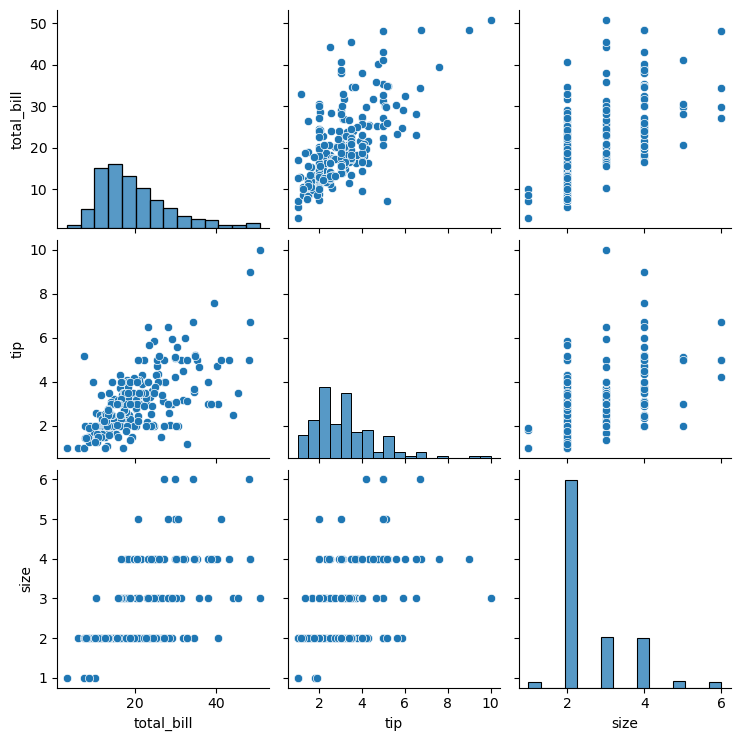

In [3]:
#pair plot

sns.pairplot(tips)
plt.show()

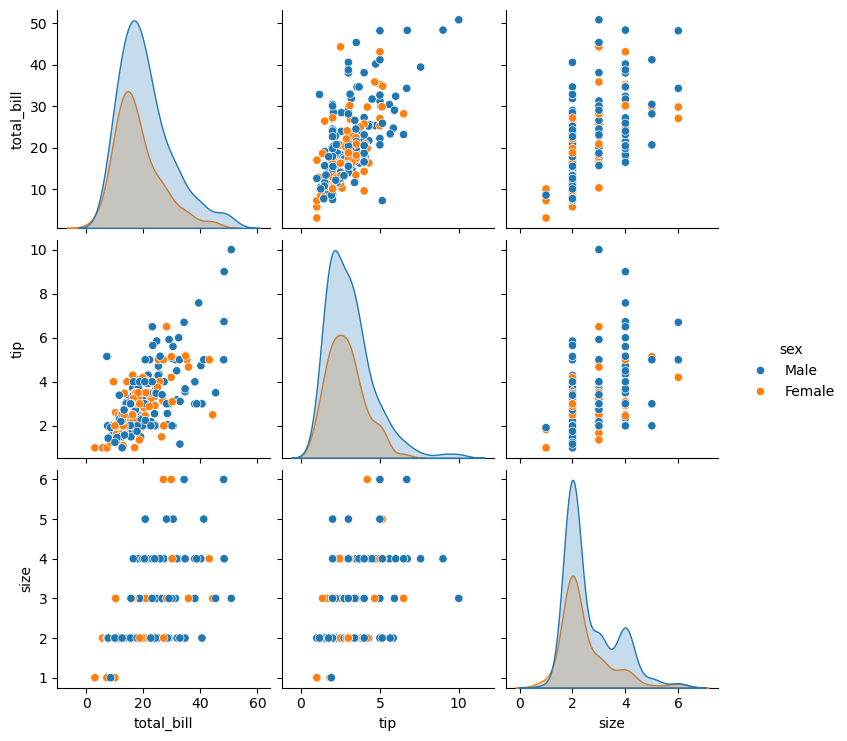

In [4]:
# pair plot with hue

sns.pairplot(
    tips,
    hue='sex'
)
plt.show()

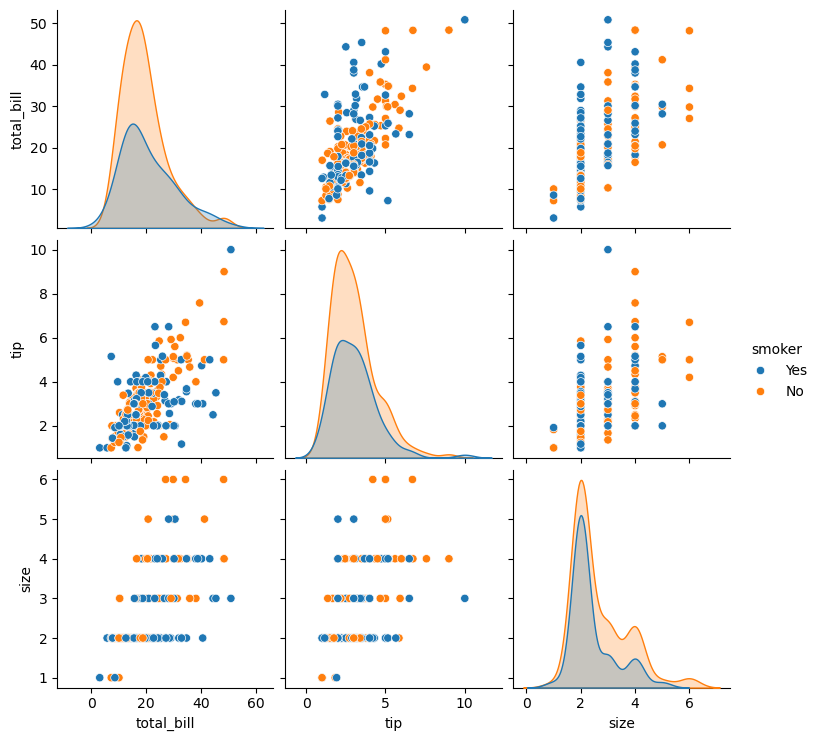

In [5]:
# pair plot with smoker

sns.pairplot(
    tips,
    hue='smoker'
)
plt.show()

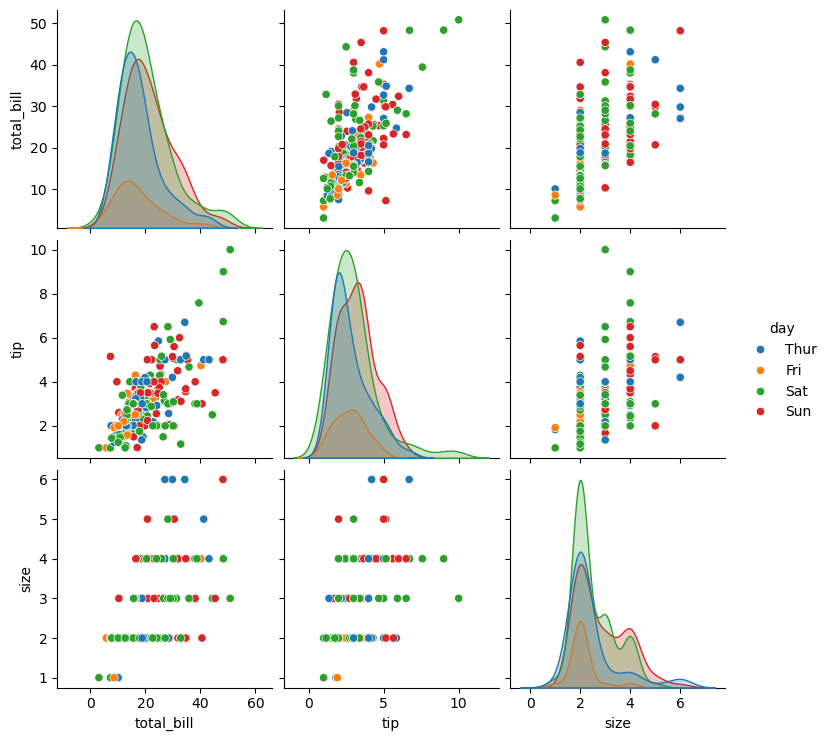

In [6]:
# pair plot by day

sns.pairplot(
    tips,
    hue='day'
)

plt.show()

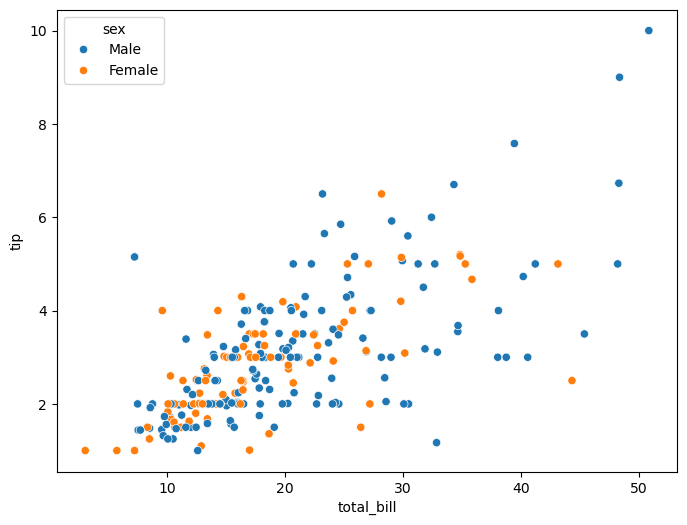

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    data=tips
)

plt.show()

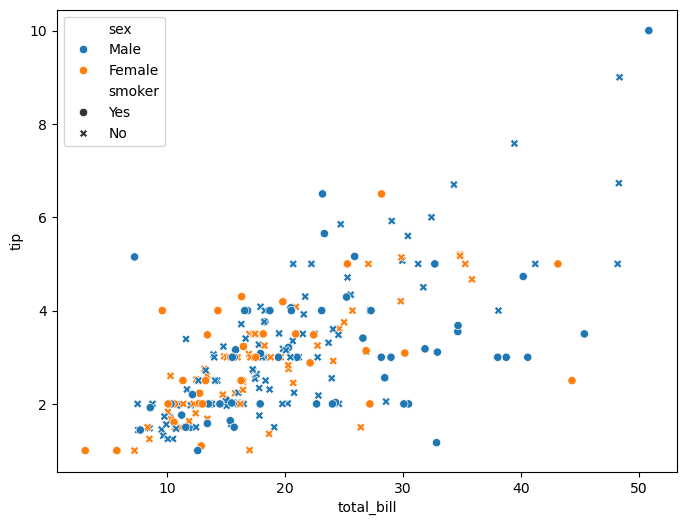

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    style='smoker',
    data=tips
)

plt.show()

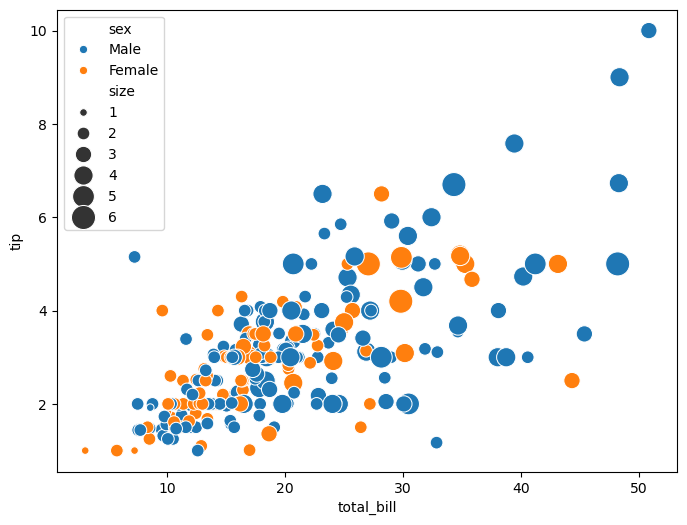

In [9]:
#bubble plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    size='size',
    data=tips,
    sizes=(30,300)
)

plt.show()

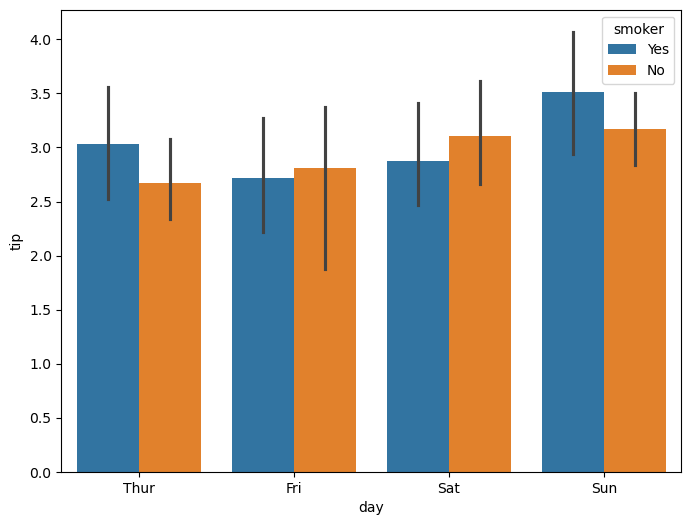

In [10]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='day',
    y='tip',
    hue='smoker',
    data=tips
)

plt.show()

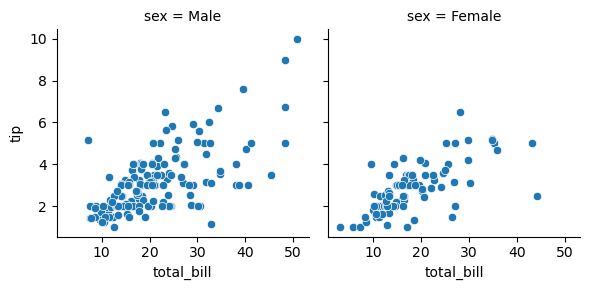

In [11]:
# facet grid

g = sns.FacetGrid(
    tips,
    col='sex'
)

g.map(
    sns.scatterplot,
    'total_bill',
    'tip'
)

plt.show()

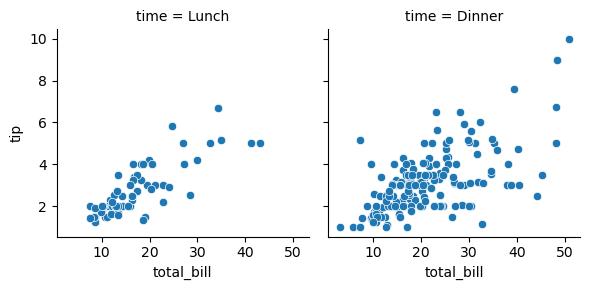

In [12]:
g = sns.FacetGrid(
    tips,
    col='time'
)

g.map(
    sns.scatterplot,
    'total_bill',
    'tip'
)

plt.show()

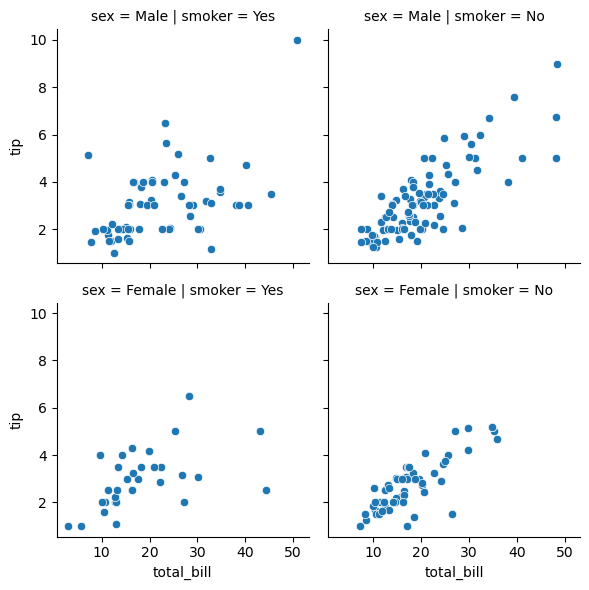

In [13]:
g = sns.FacetGrid(
    tips,
    row='sex',
    col='smoker'
)

g.map(
    sns.scatterplot,
    'total_bill',
    'tip'
)

plt.show()

In [14]:
pivot = tips.pivot_table(
    values='tip',
    index='day',
    columns='sex',
    aggfunc='mean'
)

pivot

C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_8472\2474783835.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tips.pivot_table(


sex,Male,Female
day,,
Thur,2.980333,2.575625
Fri,2.693000,2.781111
Sat,3.083898,2.801786
Sun,3.220345,3.367222


In [15]:
corr = tips.corr(numeric_only=True)

corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [16]:
tips.groupby(
    ['day','sex']
)['tip'].mean()

C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_8472\4215360992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby(


day   sex   
Thur  Male      2.980333
      Female    2.575625
Fri   Male      2.693000
      Female    2.781111
Sat   Male      3.083898
      Female    2.801786
Sun   Male      3.220345
      Female    3.367222
Name: tip, dtype: float64

In [17]:
pd.crosstab(
    tips['day'],
    tips['sex']
)

sex,Male,Female
day,,
Thur,30,32
Fri,10,9
Sat,59,28
Sun,58,18


In [19]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)

print(Q1)
print(Q3)

13.3475
24.127499999999998


In [20]:
IQR = Q3 - Q1

print(IQR)

10.779999999999998


In [21]:
lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print(lower_limit)
print(upper_limit)

-2.8224999999999945
40.29749999999999


In [22]:
# detect outliers

outliers = tips[
    (tips['total_bill'] < lower_limit) |
    (tips['total_bill'] > upper_limit)
]

outliers

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


In [24]:
# count outliers

len(outliers)


9

In [26]:
# remove outliers

tips_clean = tips[
    (tips['total_bill'] >= lower_limit) &
    (tips['total_bill'] <= upper_limit)
]

In [27]:
print("Original Shape :", tips.shape)

print("New Shape :", tips_clean.shape)

Original Shape : (244, 7)
New Shape : (235, 7)


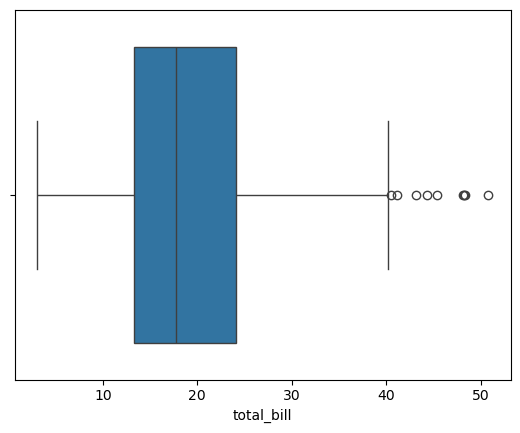

In [28]:
sns.boxplot(x=tips['total_bill'])

plt.show()

In [29]:
# z-score

from scipy.stats import zscore

z = np.abs(zscore(tips['total_bill']))

z


array([3.14711305e-01, 1.06323531e+00, 1.37779900e-01, 4.38315103e-01,
       5.40744704e-01, 6.19536705e-01, 1.23995452e+00, 7.98507107e-01,
       5.34203307e-01, 5.63468908e-01, 1.07111451e+00, 1.74175992e+00,
       4.91430507e-01, 1.52624903e-01, 5.57840908e-01, 2.01939101e-01,
       1.06436091e+00, 3.93503306e-01, 3.16962505e-01, 9.72582994e-02,
       2.10030504e-01, 5.67366990e-02, 4.52034507e-01, 2.21000952e+00,
       3.83349840e-03, 2.22412104e-01, 7.22178510e-01, 7.98719310e-01,
       2.15446301e-01, 1.53017018e-02, 1.15215771e+00, 1.61629703e-01,
       5.31952107e-01, 1.01760699e-01, 2.25788904e-01, 4.81087904e-01,
       3.91252106e-01, 3.21464905e-01, 1.23359303e-01, 1.29264551e+00,
       4.21643306e-01, 2.61808105e-01, 6.58019309e-01, 1.13752491e+00,
       1.19471831e+00, 1.68383303e-01, 2.75103101e-01, 1.41983831e+00,
       9.86482309e-01, 1.96523304e-01, 8.15603311e-01, 1.06886331e+00,
       1.69110792e+00, 1.10825931e+00, 6.49927905e-01, 3.33113020e-02,
      

In [30]:
tips[z > 3]

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
